# Red neuronal clasificación imágenes

- Objetivo: crear una red neuronal utilizando el dataset MNIST de letras para desarrollar un modelo de aprendizaje automático capaz de reconocer y clasificar imágenes de dígitos escritos a mano. 

author: Virginia Ordoño Bernier - april 2024

#

### 1. Carga de datos

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Crear un grupo de validación para ajustar los hiperparámetros
validation_images = train_images[:5000]
validation_labels = train_labels[:5000]
train_images = train_images[5000:]
train_labels = train_labels[5000:]

### 2. Dimensiones de los datos

In [31]:
import numpy as np

print(f"Datos de entrenamiento: {train_images.shape}")
print(f"Datos de prueba: {test_images.shape}")
print(f"Etiquetas de entrenamiento: {train_labels.shape}")
print(f"Etiquetas de prueba: {test_labels.shape}")
print(f"Etiquetas de las imñagenes: {np.unique(train_labels)}")


Datos de entrenamiento: (55000, 28, 28)
Datos de prueba: (10000, 28, 28)
Etiquetas de entrenamiento: (55000,)
Etiquetas de prueba: (10000,)
Etiquetas de las imñagenes: [0 1 2 3 4 5 6 7 8 9]


### 3. Muestra de una imagen del conjunto

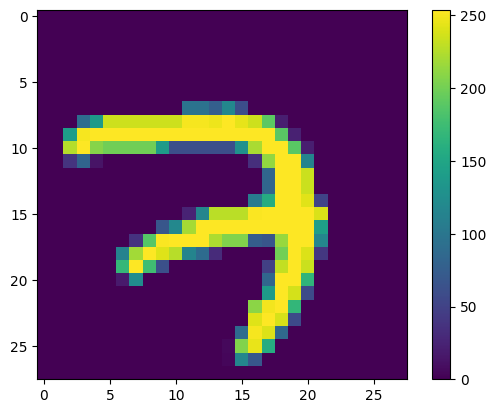

In [32]:
from matplotlib import pyplot as plt

plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

### 4. Normalización de los valores de los píxeles entre 0 y 1

In [33]:
# La normalización de los datos mejora la convergencia del modelo
train_images = train_images / 255.0
test_images = test_images / 255.0

### 5. Configuración del modelo

In [34]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu', kernel_initializer='he_uniform'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_5 (Flatten)         (None, 784)               0         
                                                                 
 dense_17 (Dense)            (None, 128)               100480    
                                                                 
 dense_18 (Dense)            (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 6. Entrenamiento y validación del modelo - Early Stopping

Mínima pérdida de validación: 11.0650
Máxima precisión de entrenamiento: 0.9794


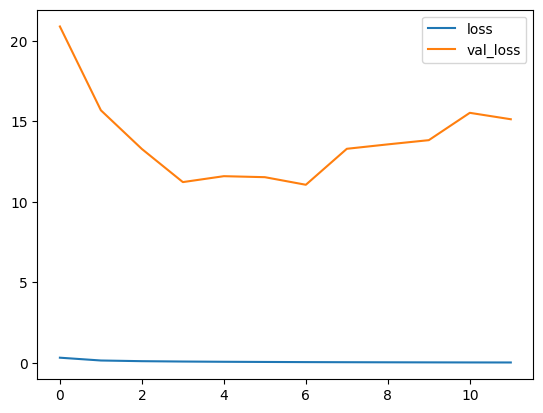

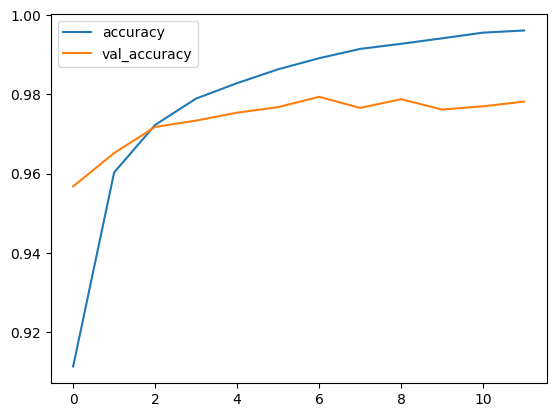

In [35]:
import pandas as pd

# Configura el modelo para el entrenamiento
model.compile(
    optimizer='adam', # Adam se encarga de ajustar los pesos de la red 
    loss='sparse_categorical_crossentropy', # Función de pérdida que se usa para clasificación multiclase
    metrics=['accuracy'] # Métrica que se usa para evaluar el rendimiento de la red
) 

# Define el early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', # Elige la pérdida validación como métrica para detener el entrenamiento
    patience=5, # Épocas que se esperan sin mejora antes de detener el entrenamiento
    min_delta=0.001, # Mínima mejora en la pérdida para considerar como mejora
    restore_best_weights=True, # restaura los mejores pesos
)

# Entrena el modelo
history = model.fit(
    train_images, 
    train_labels, 
    epochs=100, 
    batch_size=64, 
    validation_data=(validation_images, validation_labels),
    callbacks=[early_stopping], 
    verbose=0,
)

# Visualiza la pérdida y la precisión
history_df = pd.DataFrame(history.history)

# Pérdida
history_df.loc[:, ['loss', 'val_loss']].plot()
print(f"Mínima pérdida de validación: {history_df['val_loss'].min():0.4f}")

# Precisión
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
print(f"Máxima precisión de entrenamiento: {history_df['val_accuracy'].max():0.4f}")

### 7. Evaluación del modelo

In [36]:
# Evalúa el modelo
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=0)

print(f"Valor de pérdida: {test_loss:.4f}")
print(f"Valor de la precisión: {test_acc:.4f}")

Valor de pérdida: 0.0711
Valor de la precisión: 0.9778


### 8. Predicción sobre el conjunto de prueba

In [37]:
predictions = model.predict(test_images)

# Devuelve el índice de la clase predicha
predicted_class = np.argmax(predictions[1])

# Devuelve la etiqueta real de la imagen
real_class = test_labels[1]

print(f"Clase predicha: {predicted_class}")
print(f"Clase real: {real_class}")

313/313 [==============================] - 1s 2ms/step
Clase predicha: 2
Clase real: 2


### 9. Guardamos el modelo

In [38]:
import pickle

# guarda model y preprocessor en un archivo pickle en formato binario como un array de dos elementos
with open('./model/digits-mnist.pkl', 'wb') as model_file:
    pickle.dump((model), model_file)
